<a href="https://colab.research.google.com/github/Chaitanya-G41/Plant_disease_detection/blob/main/notebooks/02_train_stage1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
"/content/drive/MyDrive/PlantDiseaseProject/dataset/"

'/content/drive/MyDrive/PlantDiseaseProject/dataset/'

In [ ]:
import os

path = "/content/drive/MyDrive/PlantDiseaseProject/dataset/"
print(os.listdir(path))


['val', 'train']


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/PlantDiseaseProject/dataset/"))

['val', 'train']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = '/content/drive/MyDrive/PlantDiseaseProject/dataset'
TRAIN = f'{BASE}/train'
VAL   = f'{BASE}/val'

train_classes = sorted(os.listdir(TRAIN))
val_classes   = sorted(os.listdir(VAL))

print(f"Train classes : {len(train_classes)}")
print(f"Val classes   : {len(val_classes)}")
print(f"Classes match : {train_classes == val_classes}")
print()

# Count images per class
print(f"{'Class':<45} {'Train':>6} {'Val':>6}")
print("-" * 60)
total_train = total_val = 0
for cls in train_classes:
    t = len(os.listdir(f'{TRAIN}/{cls}'))
    v = len(os.listdir(f'{VAL}/{cls}'))  if cls in val_classes else 0
    total_train += t
    total_val   += v
    flag = " <<<< LOW" if t < 80 else ""
    print(f"{cls:<45} {t:>6} {v:>6}{flag}")

print("-" * 60)
print(f"{'TOTAL':<45} {total_train:>6} {total_val:>6}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train classes : 44
Val classes   : 44
Classes match : True

Class                                          Train    Val
------------------------------------------------------------
Apple___Apple_scab                               504    126
Apple___Black_rot                                496    124
Apple___Cedar_apple_rust                         220     59
Apple___healthy                                 1319    329
Blueberry___healthy                             1200    300
Cherry_(including_sour)___Powdery_mildew         840    210
Cherry_(including_sour)___healthy                680    170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    408    102
Corn_(maize)___Common_rust_                      952    238
Corn_(maize)___Northern_Leaf_Blight              788    197
Corn_(maize)___healthy                           928    232
Grape___Black_rot        

In [ ]:
# ============================================================
# CELL 1: Install dependencies
# Run once per Colab session
# ============================================================
!pip install timm==0.9.16 --quiet
!pip install torchmetrics --quiet

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4
VRAM            : 15.6 GB


In [ ]:
# ============================================================
# CELL 2: Mount Drive + verify dataset paths
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

import os

BASE      = '/content/drive/MyDrive/PlantDiseaseProject/dataset'
TRAIN_DIR = f'{BASE}/train'
VAL_DIR   = f'{BASE}/val'
SAVE_DIR  = '/content/drive/MyDrive/PlantDiseaseProject/models/stage1'

os.makedirs(SAVE_DIR, exist_ok=True)

# Verify
assert os.path.exists(TRAIN_DIR), f"Train dir not found: {TRAIN_DIR}"
assert os.path.exists(VAL_DIR),   f"Val dir not found:   {VAL_DIR}"

train_classes = sorted(os.listdir(TRAIN_DIR))
val_classes   = sorted(os.listdir(VAL_DIR))

print(f"Train classes : {len(train_classes)}")
print(f"Val classes   : {len(val_classes)}")
print(f"Classes match : {train_classes == val_classes}")
print(f"Save dir      : {SAVE_DIR}")
print("\nGuava classes found:")
for c in train_classes:
    if 'guava' in c.lower() or 'Guava' in c:
        count = len(os.listdir(f'{TRAIN_DIR}/{c}'))
        print(f"  {c} — {count} images")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train classes : 44
Val classes   : 44
Classes match : True
Save dir      : /content/drive/MyDrive/PlantDiseaseProject/models/stage1

Guava classes found:
  Guava_anthracnose — 800 images
  Guava_healthy — 800 images
  Guava_insect_bite — 800 images
  Guava_multiple — 800 images
  Guava_scorch — 800 images
  Guava_yld — 800 images


In [ ]:

# ============================================================
# CELL 3: Pull your src/ code from GitHub into Colab
# Replace with your actual GitHub URL
# ============================================================
import os

REPO_URL  = 'https://github.com/Chaitanya-G41/Plant_disease_detection'
REPO_NAME = 'Plant_disease_detection'

if os.path.exists(f'/content/{REPO_NAME}'):
    # Already cloned — just pull latest changes
    %cd /content/{REPO_NAME}
    !git pull origin main
else:
    %cd /content
    !git clone {REPO_URL}
    %cd /content/{REPO_NAME}

# Add src/ to Python path so we can import from it
import sys
sys.path.insert(0, f'/content/{REPO_NAME}')

# Verify imports work
from src.preprocess import get_transforms
from src.dataset    import get_dataloaders, get_class_weights
from src.model      import build_stage1_model
from src.train      import train
from src.evaluate   import evaluate_model, plot_training_history

print("All imports successful.")


/content
Cloning into 'Plant_disease_detection'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 24 (delta 3), reused 16 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (24/24), 11.66 KiB | 11.66 MiB/s, done.
Resolving deltas: 100% (3/3), done.
/content/Plant_disease_detection
All imports successful.


In [ ]:
import os
print(os.listdir('/content/Plant_disease_detection'))
import os
print(os.listdir('/content/Plant_disease_detection/src'))
sys.path.append('/content/Plant_disease_detection/src')

['rag', 'models', 'src', '.git', 'README.md', 'requirements.txt', '.gitignore', 'utils']
['dataset.py', 'evaluate.py', 'model.py', 'preprocess.py', '__init__.py', '__pycache__', 'train.py']


In [ ]:
import os
print(os.listdir('/content'))

['.config', 'Plant_disease_detection', 'drive', 'sample_data']


In [ ]:
import sys
sys.path.append('/content/Plant_disease_detection/src')

from preprocess import get_transforms

print("Import successful ✅")

Import successful ✅


In [ ]:
# ============================================================
# CELL 4: Copy dataset (FIXED & ROBUST)
# ============================================================
import shutil, time, os

# --- SAFETY CHECK: Re-define if Cell 2 variables are missing ---
if 'TRAIN_DIR' not in globals():
    print("⚠️ Warning: Paths were missing. Re-defining them now...")
    BASE      = '/content/drive/MyDrive/PlantDiseaseProject/dataset'
    TRAIN_DIR = f'{BASE}/train'
    VAL_DIR   = f'{BASE}/val'
# ---------------------------------------------------------------

LOCAL_TRAIN = '/content/data/train'
LOCAL_VAL   = '/content/data/val'

# Create base directory
os.makedirs('/content/data', exist_ok=True)

if not os.path.exists(LOCAL_TRAIN):
    if not os.path.exists(TRAIN_DIR):
        print(f"❌ ERROR: Source folder {TRAIN_DIR} does not exist!")
        print("Check if your Google Drive is mounted and the folder name is correct.")
    else:
        print("Copying train set to local storage...")
        t0 = time.time()
        # Using !cp -r is faster and more reliable than shutil for Drive
        !cp -r "{TRAIN_DIR}" "{LOCAL_TRAIN}"
        print(f"Train copied in {time.time()-t0:.0f}s")
else:
    print("Train already in local storage.")

if not os.path.exists(LOCAL_VAL):
    if not os.path.exists(VAL_DIR):
         print(f"❌ ERROR: Source folder {VAL_DIR} does not exist!")
    else:
        print("Copying val set to local storage...")
        t0 = time.time()
        !cp -r "{VAL_DIR}" "{LOCAL_VAL}"
        print(f"Val copied in {time.time()-t0:.0f}s")
else:
    print("Val already in local storage.")

# Final verification
try:
    total_train = sum(len(os.listdir(f'{LOCAL_TRAIN}/{c}')) for c in os.listdir(LOCAL_TRAIN))
    total_val   = sum(len(os.listdir(f'{LOCAL_VAL}/{c}'))   for c in os.listdir(LOCAL_VAL))
    print(f"\nLocal train images : {total_train}")
    print(f"Local val images   : {total_val}")
except Exception as e:
    print(f"Error counting files: {e}")

Exception in thread QueueFeederThread:
Traceback (most recent call last):
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 259, in _feed
    reader_close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 178, in close
    self._close()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 377, in _close
    _close(self._handle)
OSError: [Errno 9] Bad file descriptor

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 291, in _feed
    queue_sem.release()
ValueError: semaphore or lock released too many times


Train already in local storage.
Val already in local storage.

Local train images : 30146
Local val images   : 2


In [ ]:
# ============================================================
# CELL 5: All hyperparameters in one place
# Change only this cell if you want to experiment
# ============================================================

CONFIG = {
    # Paths
    'train_dir'      : LOCAL_TRAIN,
    'val_dir'        : LOCAL_VAL,
    'save_dir'       : SAVE_DIR,

    # Model
    'num_classes'    : 44,
    'pretrained'     : True,

    # Training
    'batch_size'     : 32,     # T4 has 15GB VRAM — 32 is safe
    'num_epochs'     : 30,
    'lr'             : 2e-4,   # slightly higher than default for full fine-tune
    'weight_decay'   : 0.05,
    'warmup_epochs'  : 5,
    'patience'       : 7,      # early stopping

    # Reproducibility
    'seed'           : 42,
    'num_workers'    : 2,

    # Device
    'device'         : 'cuda' if torch.cuda.is_available() else 'cpu',
}

# Set seeds for reproducibility — important for paper
import random
import numpy as np

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(CONFIG['seed'])

# T4-specific optimization
torch.backends.cudnn.benchmark = True  # faster conv on fixed input size

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k:<20} : {v}")


Total classes     : 4
PlantVillage      : 4
Guava (target)    : 0 → []
Train images      : 2471
Val images        : 2
Batch size        : 32
Weighted sampler  : True
Class mapping saved: /content/drive/MyDrive/PlantDiseaseProject/models/stage1/class_mapping.json


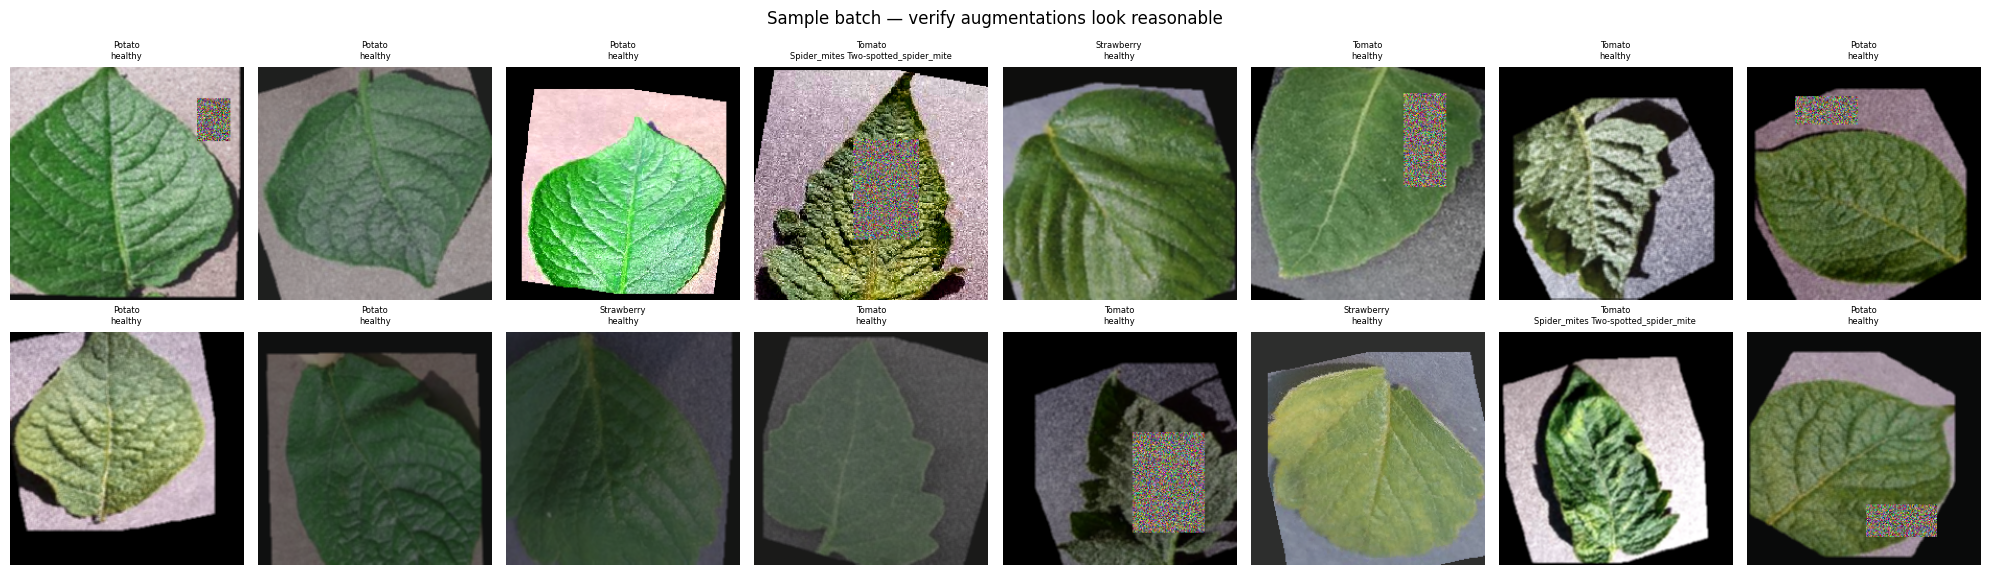

Sample batch saved to Drive.


In [ ]:
# ============================================================
# CELL 6: Build dataloaders with class weighting
# ============================================================

train_loader, val_loader, class_names, idx_to_class = get_dataloaders(
    train_dir            = CONFIG['train_dir'],
    val_dir              = CONFIG['val_dir'],
    batch_size           = CONFIG['batch_size'],
    num_workers          = CONFIG['num_workers'],
    use_weighted_sampler = True   # handles Orange(4415) vs Potato_healthy(120)
)

# Compute class weights for loss function
from torchvision.datasets import ImageFolder
from src.preprocess import get_transforms

_tmp_dataset  = ImageFolder(CONFIG['train_dir'], transform=get_transforms('train'))
class_weights = get_class_weights(_tmp_dataset)
del _tmp_dataset

# Save class mapping to Drive — needed later for inference and RAG
import json
mapping_path = f"{SAVE_DIR}/class_mapping.json"
with open(mapping_path, 'w') as f:
    json.dump({
        'class_names'  : class_names,
        'idx_to_class' : idx_to_class
    }, f, indent=2)
print(f"Class mapping saved: {mapping_path}")

# Visualize one batch to confirm transforms are working
import matplotlib.pyplot as plt
from src.preprocess import get_inverse_transform

inv_transform = get_inverse_transform()
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for i, ax in enumerate(axes.flatten()):
    img = inv_transform(images[i]).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img)
    ax.set_title(class_names[labels[i].item()].replace('___', '\n'), fontsize=6)
    ax.axis('off')
plt.suptitle('Sample batch — verify augmentations look reasonable', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/sample_batch.png', dpi=100)
plt.show()
print("Sample batch saved to Drive.")


In [ ]:
# ============================================================
# CELL 7: Build Stage 1 model
# DeiT-tiny pretrained on ImageNet → fine-tune on 44 classes
# ============================================================

model = build_stage1_model(
    num_classes = CONFIG['num_classes'],
    pretrained  = CONFIG['pretrained']
)

model = model.to(CONFIG['device'])

# Sanity check — forward pass with dummy input
with torch.no_grad():
    dummy     = torch.randn(2, 3, 224, 224).to(CONFIG['device'])
    dummy_out = model(dummy)
    print(f"Forward pass OK — output shape: {dummy_out.shape}")
    # Should be (2, 44)

# Estimate training time on T4
import math
batches_per_epoch = math.ceil(48229 / CONFIG['batch_size'])
secs_per_batch    = 0.15   # ~150ms per batch on T4
est_mins          = (batches_per_epoch * secs_per_batch * CONFIG['num_epochs']) / 60
print(f"\nEstimated training time on T4 : ~{est_mins:.0f} mins")
print(f"Batches per epoch             : {batches_per_epoch}")
print(f"(Early stopping may end sooner)")


In [ ]:
# ============================================================
# CELL 8: Run Stage 1 training
#
# This is the long-running cell — ~60-90 mins on T4.
# Do NOT close the browser tab. If session disconnects,
# the best checkpoint is already saved to Drive — you can
# resume from it.
# ============================================================

history, best_val_acc = train(
    model          = model,
    train_loader   = train_loader,
    val_loader     = val_loader,
    save_path      = CONFIG['save_dir'],
    stage          = 1,
    num_epochs     = CONFIG['num_epochs'],
    lr             = CONFIG['lr'],
    weight_decay   = CONFIG['weight_decay'],
    warmup_epochs  = CONFIG['warmup_epochs'],
    patience       = CONFIG['patience'],
    class_weights  = class_weights,
    device         = CONFIG['device']
)

print(f"\nStage 1 complete.")
print(f"Best val accuracy : {best_val_acc:.2f}%")
print(f"Checkpoint saved  : {CONFIG['save_dir']}/stage1_best.pth")


In [ ]:
# ============================================================
# CELL 9: Full evaluation — all 44 classes
# Generates confusion matrix + per-class F1 for the paper
# ============================================================

# Load best checkpoint for evaluation
best_ckpt = f"{CONFIG['save_dir']}/stage1_best.pth"
checkpoint = torch.load(best_ckpt, map_location=CONFIG['device'])
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best checkpoint (epoch {checkpoint['epoch']}, "
      f"val acc {checkpoint['val_acc']:.2f}%)")

metrics_all = evaluate_model(
    model        = model,
    val_loader   = val_loader,
    class_names  = class_names,
    save_dir     = CONFIG['save_dir'],
    stage        = 1,
    device       = CONFIG['device'],
    guava_only   = False
)


In [ ]:

# ============================================================
# CELL 10: Guava-only evaluation
# This is the number that goes in your paper as Stage 1
# guava baseline — before the specialized Stage 2 fine-tuning
# ============================================================

metrics_guava = evaluate_model(
    model        = model,
    val_loader   = val_loader,
    class_names  = class_names,
    save_dir     = CONFIG['save_dir'],
    stage        = 1,
    device       = CONFIG['device'],
    guava_only   = True
)

print("\n" + "="*50)
print("SUMMARY FOR PAPER")
print("="*50)
print(f"Stage 1 — All classes  accuracy : {metrics_all['accuracy']:.2f}%")
print(f"Stage 1 — All classes  macro F1 : {metrics_all['macro_f1']:.4f}")
print(f"Stage 1 — Guava only   accuracy : {metrics_guava['accuracy']:.2f}%")
print(f"Stage 1 — Guava only   macro F1 : {metrics_guava['macro_f1']:.4f}")
print("="*50)
print("\nNote: Guava accuracy here is the BASELINE.")
print("Stage 2 fine-tuning should improve this significantly.")

UnidentifiedImageError: Caught UnidentifiedImageError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/worker.py", line 358, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/datasets/folder.py", line 245, in __getitem__
    sample = self.loader(path)
             ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/datasets/folder.py", line 284, in default_loader
    return pil_loader(path)
           ^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torchvision/datasets/folder.py", line 263, in pil_loader
    img = Image.open(f)
  

In [ ]:
# ============================================================
# DIAGNOSIS CELL — run before Stage 2
# Checks for data leakage and overfitting signals
# ============================================================
import os
import hashlib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict

def file_hash(path):
    """MD5 hash of image file — detects exact duplicates."""
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

print("Checking for duplicate images between train and val...")
print("(This may take 2-3 minutes)\n")

train_hashes = {}
val_hashes   = {}

# Hash all guava train images
for cls in os.listdir(LOCAL_TRAIN):
    if 'Guava' not in cls:
        continue
    for img in os.listdir(f'{LOCAL_TRAIN}/{cls}'):
        path = f'{LOCAL_TRAIN}/{cls}/{img}'
        h    = file_hash(path)
        train_hashes[h] = f'{cls}/{img}'

# Hash all guava val images
for cls in os.listdir(LOCAL_VAL):
    if 'Guava' not in cls:
        continue
    for img in os.listdir(f'{LOCAL_VAL}/{cls}'):
        path = f'{LOCAL_VAL}/{cls}/{img}'
        h    = file_hash(path)
        val_hashes[h] = f'{cls}/{img}'

# Find overlap
overlap = set(train_hashes.keys()) & set(val_hashes.keys())
print(f"Guava train images : {len(train_hashes)}")
print(f"Guava val images   : {len(val_hashes)}")
print(f"Exact duplicates   : {len(overlap)}")

if len(overlap) > 0:
    print("\nDATA LEAKAGE CONFIRMED — these images appear in both sets:")
    for h in list(overlap)[:5]:
        print(f"  Train: {train_hashes[h]}")
        print(f"  Val  : {val_hashes[h]}")
else:
    print("\nNo exact duplicates found.")
    print("Leakage may still exist via near-duplicates or same-source batches.")

# ── Check train loss vs val loss gap ──────────────────────────
import json
with open(f'{SAVE_DIR}/stage1_history.json') as f:
    history = json.load(f)

last5 = history[-5:]
print("\nLast 5 epochs — train vs val loss:")
print(f"{'Epoch':<8} {'Train Loss':<14} {'Val Loss':<12} {'Gap'}")
print("-" * 45)
for h in last5:
    gap  = h['val_loss'] - h['train_loss']
    flag = " ← OVERFIT" if gap > 0.1 else ""
    print(f"{h['epoch']:<8} {h['train_loss']:<14.4f} "
          f"{h['val_loss']:<12.4f} {gap:+.4f}{flag}")

# ── Visualise what model actually sees ────────────────────────
print("\nVisualising attention on guava val images...")
from src.model import get_attention_maps
from src.preprocess import get_transforms, get_inverse_transform

model.eval()
val_transform = get_transforms('val')
inv_transform = get_inverse_transform()

guava_val_dir = f'{LOCAL_VAL}/Guava_anthracnose'
sample_imgs   = os.listdir(guava_val_dir)[:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, img_name in enumerate(sample_imgs):
    img_path = f'{guava_val_dir}/{img_name}'
    img_pil  = Image.open(img_path).convert('RGB')
    img_t    = val_transform(img_pil).unsqueeze(0).to(CONFIG['device'])

    attn_maps = get_attention_maps(model, img_t)

    # Average attention from last layer, all heads, cls token → patches
    last_attn = attn_maps[-1][0]           # (heads, seq, seq)
    cls_attn  = last_attn[:, 0, 1:]        # cls token attending to patches
    cls_attn  = cls_attn.mean(0)           # average over heads
    cls_attn  = cls_attn.reshape(14, 14)   # 224/16 = 14 patches
    cls_attn  = cls_attn.cpu().numpy()
    cls_attn  = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min())

    # Resize attention to image size
    import cv2
    attn_resized = cv2.resize(cls_attn, (224, 224))

    # Original image
    orig = inv_transform(img_t[0].cpu()).permute(1,2,0).clamp(0,1).numpy()
    axes[0][i].imshow(orig)
    axes[0][i].set_title(f'Original\n{img_name[:20]}', fontsize=8)
    axes[0][i].axis('off')

    # Attention overlay
    axes[1][i].imshow(orig)
    axes[1][i].imshow(attn_resized, alpha=0.5, cmap='jet')
    axes[1][i].set_title('Attention map\n(what model focuses on)', fontsize=8)
    axes[1][i].axis('off')

plt.suptitle('Stage 1 attention maps — Guava anthracnose\n'
             'Red = high attention. Should focus on disease spots, not background.',
             fontsize=10)
plt.tight_layout()
attn_path = f'{SAVE_DIR}/stage1_attention_maps.png'
plt.savefig(attn_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Attention maps saved: {attn_path}")
print("\nLook at the attention maps carefully:")
print("  GOOD: Red regions on disease spots / leaf texture")
print("  BAD : Red regions on background / borders / uniform areas")

In [ ]:
# ============================================================
# DIAGNOSIS CELL — run before Stage 2
# Checks for data leakage and overfitting signals
# ============================================================
import os
import hashlib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import defaultdict

def file_hash(path):
    """MD5 hash of image file — detects exact duplicates."""
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

print("Checking for duplicate images between train and val...")
print("(This may take 2-3 minutes)\n")

train_hashes = {}
val_hashes   = {}

# Hash all guava train images
for cls in os.listdir(LOCAL_TRAIN):
    if 'Guava' not in cls:
        continue
    for img in os.listdir(f'{LOCAL_TRAIN}/{cls}'):
        path = f'{LOCAL_TRAIN}/{cls}/{img}'
        h    = file_hash(path)
        train_hashes[h] = f'{cls}/{img}'

# Hash all guava val images
for cls in os.listdir(LOCAL_VAL):
    if 'Guava' not in cls:
        continue
    for img in os.listdir(f'{LOCAL_VAL}/{cls}'):
        path = f'{LOCAL_VAL}/{cls}/{img}'
        h    = file_hash(path)
        val_hashes[h] = f'{cls}/{img}'

# Find overlap
overlap = set(train_hashes.keys()) & set(val_hashes.keys())
print(f"Guava train images : {len(train_hashes)}")
print(f"Guava val images   : {len(val_hashes)}")
print(f"Exact duplicates   : {len(overlap)}")

if len(overlap) > 0:
    print("\nDATA LEAKAGE CONFIRMED — these images appear in both sets:")
    for h in list(overlap)[:5]:
        print(f"  Train: {train_hashes[h]}")
        print(f"  Val  : {val_hashes[h]}")
else:
    print("\nNo exact duplicates found.")
    print("Leakage may still exist via near-duplicates or same-source batches.")

# ── Check train loss vs val loss gap ──────────────────────────
import json
with open(f'{SAVE_DIR}/stage1_history.json') as f:
    history = json.load(f)

last5 = history[-5:]
print("\nLast 5 epochs — train vs val loss:")
print(f"{'Epoch':<8} {'Train Loss':<14} {'Val Loss':<12} {'Gap'}")
print("-" * 45)
for h in last5:
    gap  = h['val_loss'] - h['train_loss']
    flag = " ← OVERFIT" if gap > 0.1 else ""
    print(f"{h['epoch']:<8} {h['train_loss']:<14.4f} "
          f"{h['val_loss']:<12.4f} {gap:+.4f}{flag}")

# ── Visualise what model actually sees ────────────────────────
print("\nVisualising attention on guava val images...")
from src.model import get_attention_maps
from src.preprocess import get_transforms, get_inverse_transform

model.eval()
val_transform = get_transforms('val')
inv_transform = get_inverse_transform()

guava_val_dir = f'{LOCAL_VAL}/Guava_anthracnose'
sample_imgs   = os.listdir(guava_val_dir)[:4]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, img_name in enumerate(sample_imgs):
    img_path = f'{guava_val_dir}/{img_name}'
    img_pil  = Image.open(img_path).convert('RGB')
    img_t    = val_transform(img_pil).unsqueeze(0).to(CONFIG['device'])

    attn_maps = get_attention_maps(model, img_t)

    # Average attention from last layer, all heads, cls token → patches
    last_attn = attn_maps[-1][0]           # (heads, seq, seq)
    cls_attn  = last_attn[:, 0, 1:]        # cls token attending to patches
    cls_attn  = cls_attn.mean(0)           # average over heads
    cls_attn  = cls_attn.reshape(14, 14)   # 224/16 = 14 patches
    cls_attn  = cls_attn.cpu().numpy()
    cls_attn  = (cls_attn - cls_attn.min()) / (cls_attn.max() - cls_attn.min())

    # Resize attention to image size
    import cv2
    attn_resized = cv2.resize(cls_attn, (224, 224))

    # Original image
    orig = inv_transform(img_t[0].cpu()).permute(1,2,0).clamp(0,1).numpy()
    axes[0][i].imshow(orig)
    axes[0][i].set_title(f'Original\n{img_name[:20]}', fontsize=8)
    axes[0][i].axis('off')

    # Attention overlay
    axes[1][i].imshow(orig)
    axes[1][i].imshow(attn_resized, alpha=0.5, cmap='jet')
    axes[1][i].set_title('Attention map\n(what model focuses on)', fontsize=8)
    axes[1][i].axis('off')

plt.suptitle('Stage 1 attention maps — Guava anthracnose\n'
             'Red = high attention. Should focus on disease spots, not background.',
             fontsize=10)
plt.tight_layout()
attn_path = f'{SAVE_DIR}/stage1_attention_maps.png'
plt.savefig(attn_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"Attention maps saved: {attn_path}")
print("\nLook at the attention maps carefully:")
print("  GOOD: Red regions on disease spots / leaf texture")
print("  BAD : Red regions on background / borders / uniform areas")


Checking for duplicate images between train and val...
(This may take 2-3 minutes)



NameError: name 'LOCAL_TRAIN' is not defined